![](https://www.foxchase.org/sites/fccc/files/breast-cancer-awareness.jpg)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/breast-cancer-wisconsin-data/data.csv


In [2]:
cancer_dataset = pd.read_csv("/kaggle/input/breast-cancer-wisconsin-data/data.csv")

## Dataset Information

* Dataset Characteristics: Multivariate
* Attribute Characteristics: Real
* Attribute Characteristics: Classification
* Number of Instances: 569
* Number of Attributes: 32
* Missing Values: No

## Column Names and Meanings
* id: ID number
* diagnosis: The diagnosis of breast tissues (M = malignant, B = benign)
* radius_mean: mean of distances from center to points on the perimeter
* texture_mean: standard deviation of gray-scale values
* perimeter_mean: mean size of the core tumor
* area_mean: area of the tumor
* smoothness_mean: mean of local variation in radius lengths
* compactness_mean: mean of perimeter^2 / area - 1.0
* concavity_mean: mean of severity of concave portions of the contour
* concave_points_mean: mean for number of concave portions of the contour
* symmetry_mean
* fractal_dimension_mean: mean for "coastline approximation" - 1
* radius_se: standard error for the mean of distances from center to points on the perimeter
* texture_se: standard error for standard deviation of gray-scale values
* perimeter_se
* area_se
* smoothness_se: standard error for local variation in radius lengths
* compactness_se: standard error for perimeter^2 / area - 1.0
* concavity_se: standard error for severity of concave portions of the contour
* concave_points_se: standard error for number of concave portions of the contour
* symmetry_se
* fractal_dimension_se: standard error for "coastline approximation" - 1
* radius_worst: "worst" or largest mean value for mean of distances from center to points on the perimeter
* texture_worst: "worst" or largest mean value for standard deviation of gray-scale values
* perimeter_worst
* area_worst
* smoothness_worst: "worst" or largest mean value for local variation in radius lengths
* compactness_worst: "worst" or largest mean value for perimeter^2 / area - 1.0
* concavity_worst: "worst" or largest mean value for severity of concave portions of the contour
* concave_points_worst: "worst" or largest mean value for number of concave portions of the contour
* symmetry_worst
* fractal_dimension_worst: "worst" or largest mean value for "coastline approximation" - 1

In [3]:
cancer_dataset

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


![](https://miro.medium.com/max/4000/0*0XRrnsr7h5hebu8r.png)

In [4]:
print(cancer_dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Since we do not need "id" and "Unnamed: 32" columns, I am going to drop them.

In [5]:
cancer_dataset.drop(["id", "Unnamed: 32"], axis = 1, inplace=True)

In [6]:
cancer_dataset

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In "diagnosis" column, instead of using M or B, I will convert them 0's and 1's.

In [7]:
cancer_dataset.diagnosis = [1 if i == "M" else 0 for i in cancer_dataset.diagnosis]

In [8]:
print(cancer_dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [9]:
cancer_dataset

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [10]:
x = cancer_dataset.drop(["diagnosis"], axis = 1)

In [11]:
type(x)

pandas.core.frame.DataFrame

In [12]:
x

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [13]:
y = cancer_dataset["diagnosis"].values

In [14]:
type(y)

numpy.ndarray

In [15]:
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,

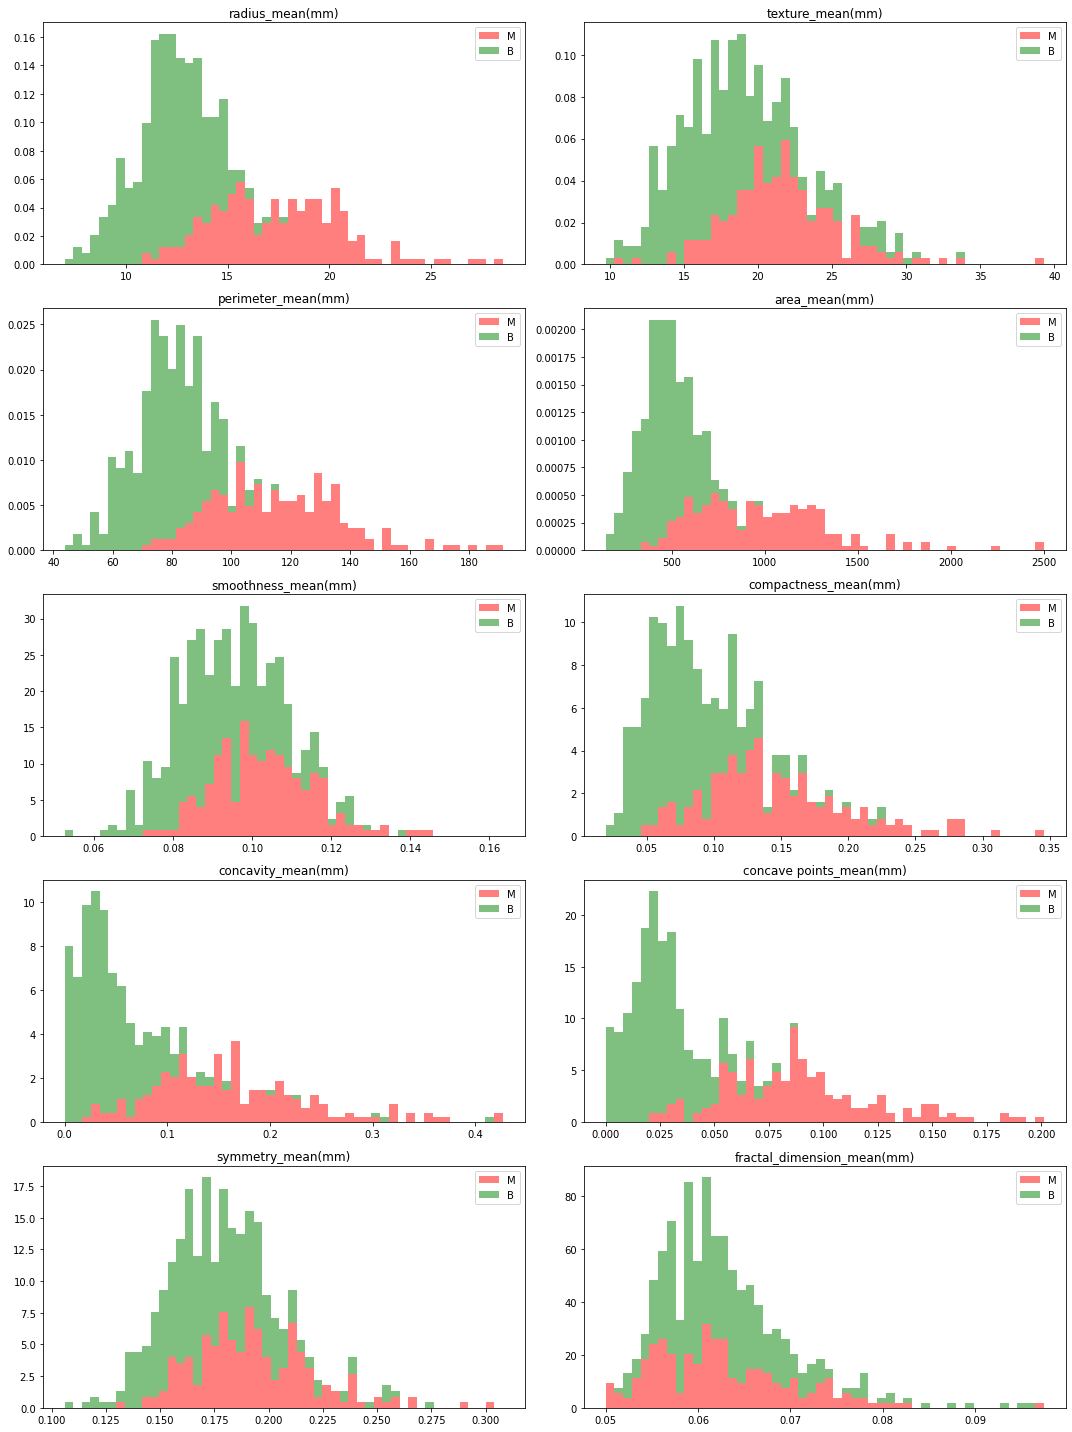

In [16]:
features_mean=list(x)
dfM = cancer_dataset[cancer_dataset["diagnosis"] == 1]
dfB = cancer_dataset[cancer_dataset["diagnosis"] == 0]
plt.rcParams.update({"font.size": 10})
fig, axes = plt.subplots(nrows = 5, ncols = 2, figsize=(15,20))
axes = axes.ravel()

for idx,ax in enumerate(axes):
    ax.figure
    binwidth= (max(cancer_dataset[features_mean[idx]]) - min(cancer_dataset[features_mean[idx]]))/50
    ax.hist([dfM[features_mean[idx]],dfB[features_mean[idx]]], bins=np.arange(min(cancer_dataset[features_mean[idx]]),
            max(cancer_dataset[features_mean[idx]]) + binwidth, binwidth) , alpha=0.5, stacked=True, density = True,
            label=["M", "B"], color = ["red","green"])
    ax.legend(loc = "upper right")
    ax.set_title(features_mean[idx] + "(mm)")
plt.tight_layout()
plt.show()

## Normalization

In [17]:
x = (x - np.min(x)) / (np.max(x) - np.min(x)).values    # (x-min(x))/(max(x)-minx)) -> Normalization formula

In [18]:
x

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,0.690000,0.428813,0.678668,0.566490,0.526948,0.296055,0.571462,0.690358,0.336364,0.132056,...,0.623266,0.383262,0.576174,0.452664,0.461137,0.178527,0.328035,0.761512,0.097575,0.105667
565,0.622320,0.626987,0.604036,0.474019,0.407782,0.257714,0.337395,0.486630,0.349495,0.113100,...,0.560655,0.699094,0.520892,0.379915,0.300007,0.159997,0.256789,0.559450,0.198502,0.074315
566,0.455251,0.621238,0.445788,0.303118,0.288165,0.254340,0.216753,0.263519,0.267677,0.137321,...,0.393099,0.589019,0.379949,0.230731,0.282177,0.273705,0.271805,0.487285,0.128721,0.151909
567,0.644564,0.663510,0.665538,0.475716,0.588336,0.790197,0.823336,0.755467,0.675253,0.425442,...,0.633582,0.730277,0.668310,0.402035,0.619626,0.815758,0.749760,0.910653,0.497142,0.452315


As you see, we converted each values between 0 and 1.

## Creating the Model

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.2, random_state = 42)

![](https://miro.medium.com/max/2908/1*Hs7RCpyvj4NrjANdwiFHaQ@2x.jpeg)

In [21]:
print("xtrain shape:", xtrain.shape)
print("xtest shape:", xtest.shape)
print("ytrain shape:", ytrain.shape)
print("ytest shape:", ytest.shape)

xtrain shape: (455, 30)
xtest shape: (114, 30)
ytrain shape: (455,)
ytest shape: (114,)


In [22]:
xtrain_transpose = xtrain.T

In [23]:
xtrain_transpose.head(10)

,68,181,63,248,60,15,290,137,155,517,...,330,214,466,121,20,71,106,270,435,102
radius_mean,0.096928,0.667755,0.103744,0.173648,0.150930,0.357755,0.351602,0.210564,0.249373,0.610961,...,0.428274,0.341190,0.291495,0.552747,0.288655,0.090255,0.220503,0.345923,0.331251,0.246060
texture_mean,0.257694,0.570172,0.140345,0.524518,0.174839,0.602976,0.338857,0.192087,0.278323,0.356781,...,0.196145,0.476835,0.373013,0.250592,0.202908,0.166723,0.291512,0.240446,0.335137,0.365573
perimeter_mean,0.103656,0.683505,0.106489,0.167369,0.143459,0.365835,0.360998,0.202267,0.238270,0.599198,...,0.428512,0.339161,0.291549,0.536314,0.289130,0.103656,0.216847,0.321401,0.327068,0.231014
area_mean,0.045387,0.495228,0.049799,0.086320,0.071432,0.218579,0.215270,0.108717,0.134380,0.454083,...,0.275589,0.198176,0.166872,0.395970,0.159703,0.042630,0.114104,0.207466,0.193425,0.133701
smoothness_mean,0.487226,0.554934,0.221901,0.396678,0.548614,0.553128,0.315428,0.395053,0.306130,0.461045,...,0.381692,0.379164,0.308026,0.476393,0.495351,0.408053,0.555836,0.105263,0.481809,0.248262
compactness_mean,0.373965,0.809214,0.208975,0.162444,0.187811,0.429790,0.454635,0.151862,0.145421,0.342372,...,0.361082,0.341145,0.274584,0.277958,0.330102,0.410159,0.252500,0.022606,0.288080,0.064413
concavity_mean,0.733365,0.582709,0.140300,0.055740,0.025398,0.384021,0.319119,0.082076,0.091026,0.330600,...,0.282099,0.261246,0.254217,0.341378,0.107029,0.201640,0.165651,0.016987,0.263824,0.055834
concave points_mean,0.217445,0.743539,0.108350,0.080268,0.064115,0.366004,0.328131,0.142893,0.115855,0.468738,...,0.349950,0.321173,0.174453,0.430666,0.154573,0.142744,0.173211,0.031064,0.321223,0.087972
symmetry_mean,0.530808,0.674242,0.646970,0.422727,0.850000,0.627778,0.330303,0.340404,0.459596,0.374747,...,0.364646,0.593434,0.253535,0.457576,0.458081,0.425253,0.374242,0.226263,0.307576,0.342929
fractal_dimension_mean,0.642376,0.505897,0.414280,0.280750,0.413648,0.438290,0.462511,0.183024,0.259478,0.251053,...,0.206403,0.302654,0.215670,0.256318,0.382266,0.839090,0.320977,0.080034,0.326032,0.143429


In [24]:
xtest_transpose = xtest.T
ytrain_transpose = ytrain.T
ytest_transpose = ytest.T

In [25]:
print("Shape of the xtrain_transpose:", xtrain_transpose.shape)
print("Shape of the xtest_transpose:", xtest_transpose.shape)
print("Shape of the ytrain_transpose:", ytrain_transpose.shape)
print("Shape of the ytest_transpose:", ytest_transpose.shape)

Shape of the xtrain_transpose: (30, 455)
Shape of the xtest_transpose: (30, 114)
Shape of the ytrain_transpose: (455,)
Shape of the ytest_transpose: (114,)


## Parameter Initialization and Sigmoid Function

In the following picture, you can see the overall idea. The only difference is we want to predict if the tumor is malignant or benign.

![](https://machinethink.net/images/tensorflow-on-ios/LogisticRegression@2x.png)

In [26]:
def inialize_weights_and_bias(dimension): # dimension = 30
    w = np.full((dimension,1),0.01)
    b = 0.0
    return w,b

In [27]:
w,b = inialize_weights_and_bias(30)
print("w:", w)
print("")
print("b:",b)

w: [[0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]]

b: 0.0


### Sigmoid function:

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT_G9kn6bEs0wdfwt9lH4I5R7ZFHb7RHrUxqQ&usqp=CAU)

In [28]:
def sigmoid_function(z):
    result = 1/(1+np.exp(-z))
    return result

In [29]:
sigmoid_function(0) # The result should be 0.5.

0.5

## Forward and Backward Propagation

In [30]:
w.shape

(30, 1)

In [31]:
xtrain_transpose.shape

(30, 455)

* w.shape = (30,1)
* xtrain_transpose.shape = (30,455)

In order to do a matrix multiplication, we need to take the transpose of the weight variables.

In [32]:
def forward_and_backward_propagation(w, b, xtrain_transpose, ytrain_transpose):
    
    # ---------- Forward propagation -----------
    # z = wT . xtrain + b
    z = np.dot(w.T,xtrain_transpose) + b
    y_head = sigmoid_function(z)
    # loss = -(ylog(y^) + (1-y) * log(1-y^))
    loss_function = -(ytrain_transpose * np.log(y_head) + (1-ytrain_transpose) * np.log(1-y_head))
    cost_function = (np.sum(loss_function) / xtrain_transpose.shape[1])
    # xtrain_transpose.shape[1] -> 455 : This part is done for scaling.
    
    # --------- Backward Propagation ------------
    
    derivative_weight = (np.dot(xtrain_transpose, ((y_head-ytrain_transpose).T))) / xtrain_transpose.shape[1]
    derivative_bias = np.sum(y_head-ytrain_transpose) / xtrain_transpose.shape[1]
    gradients = {"derivative_weight": derivative_weight, "derivative_bias": derivative_bias}
    
    return cost_function, gradients  

## Updating Parameters

In [33]:
def update_parameters(w, b, x_train_transpose, y_train_transpose, learning_rate, iteration_number):
    all_costs = []
    each_10_costs = []
    index = []
    
    for i in range(iteration_number):
        
        # --------- finding cost and gradient values -----------
        
        cost, gradients = forward_and_backward_propagation(w, b, x_train_transpose, y_train_transpose)
        all_costs.append(cost)
        
        # --------- Updating weight and bias ----------
        
        w = w - learning_rate * gradients["derivative_weight"]
        b = b - learning_rate * gradients["derivative_bias"]
        
        if i % 10 == 0:
            each_10_costs.append(cost)
            index.append(i)
            print ("Cost after iteration %i: %f" %(i, cost))
            
    # Updating(learning) weights and bias parameters
    parameters = {"weight": w,"bias": b}
    plt.figure(figsize=(10,6))
    plt.plot(index, each_10_costs, color = "orange")
    plt.xticks(index, rotation='vertical')
    plt.xlabel("Iteration number")
    plt.ylabel("Cost")
    plt.show()
    return parameters, gradients, all_costs

## Prediction Part

In [34]:
def predict(w, b, xtest_transpose):
    
    z = sigmoid_function(np.dot(w.T, xtest_transpose) + b)
    prediction = np.zeros((1,xtest_transpose.shape[1]))
    
    # z > 0.5 -> y_head=1
    # z < 0.5 -> y_head=0
    
    for i in range(z.shape[1]):
        if z[0,i]<= 0.5:
            prediction[0,i] = 0
        else:
            prediction[0,i] = 1

    return prediction

## Logistic Regression

In [35]:
def logistic_regression(xtrain_transpose, ytrain_transpose, xtest_transpose, ytest_transpose, learning_rate ,  iteration_number):

    dimension =  xtrain_transpose.shape[0] 
    w, b = inialize_weights_and_bias(dimension)
    parameters, gradients, all_costs = update_parameters(w, b, xtrain_transpose, ytrain_transpose, learning_rate, iteration_number)
    
    prediction = predict(parameters["weight"],parameters["bias"],xtest_transpose)

    # Print test Errors
    print("test accuracy: {} %".format(100 - np.mean(np.abs(prediction - ytest_transpose)) * 100))

Cost after iteration 0: 0.692977
Cost after iteration 10: 0.499667
Cost after iteration 20: 0.406616
Cost after iteration 30: 0.351936
Cost after iteration 40: 0.315762
Cost after iteration 50: 0.289862
Cost after iteration 60: 0.270257
Cost after iteration 70: 0.254795
Cost after iteration 80: 0.242214
Cost after iteration 90: 0.231722
Cost after iteration 100: 0.222796
Cost after iteration 110: 0.215080
Cost after iteration 120: 0.208317
Cost after iteration 130: 0.202324
Cost after iteration 140: 0.196961
Cost after iteration 150: 0.192121
Cost after iteration 160: 0.187722
Cost after iteration 170: 0.183698
Cost after iteration 180: 0.179997
Cost after iteration 190: 0.176577
Cost after iteration 200: 0.173402
Cost after iteration 210: 0.170443
Cost after iteration 220: 0.167676
Cost after iteration 230: 0.165080
Cost after iteration 240: 0.162638
Cost after iteration 250: 0.160334
Cost after iteration 260: 0.158155
Cost after iteration 270: 0.156091
Cost after iteration 280: 0.154

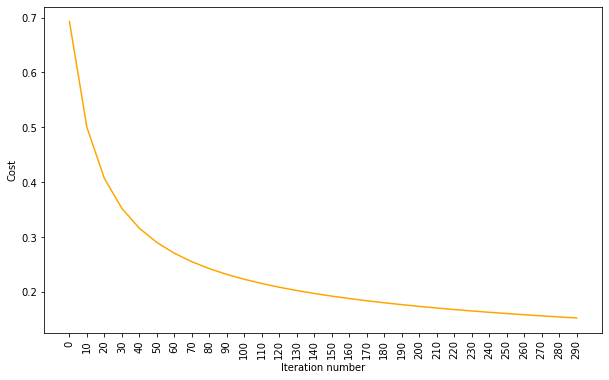

test accuracy: 96.49122807017544 %


In [36]:
logistic_regression(xtrain_transpose, ytrain_transpose, xtest_transpose, ytest_transpose, learning_rate = 1, iteration_number = 300)    